# 🍷 Wine Quality Prediction — Random Forest vs SGD vs SVC

**Objective:** Wine ke physicochemical properties (acidity, density, alcohol, etc.) se uski *quality* predict karna, aur 3 classifiers ko compare karna.

**Tech stack:** Python, pandas, numpy, scikit-learn, seaborn, matplotlib

**Dataset:** Wine Quality dataset (UCI / Kaggle, `WineQT.csv` — red wine, 1143 samples)

**Notebook ka structure**
1. Data load & inspection
2. EDA (distributions, correlation heatmap)
3. Class imbalance discussion
4. Feature engineering (quality binning)
5. Stratified train/test split
6. Model training (RF, SGD, SVC)
7. Evaluation (accuracy, classification report, confusion matrix)
8. Random Forest feature importance
9. Comparison table
10. Conclusion

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score, precision_score, recall_score)

sns.set_theme(style="whitegrid", palette="viridis")
RANDOM_STATE = 42

## 1. Load Dataset & Inspect Structure

In [2]:
df = pd.read_csv("WineQT.csv")
print("Shape:", df.shape)
df.head()

Shape: (1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.describe().T

Missing values: 0
Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [5]:
df = df.drop(columns=["Id"])
features = [c for c in df.columns if c != "quality"]
print(len(features), "features:", features)

11 features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


### Class distribution of quality scores

         count  percent
quality                
3            6     0.52
4           33     2.89
5          483    42.26
6          462    40.42
7          143    12.51
8           16     1.40


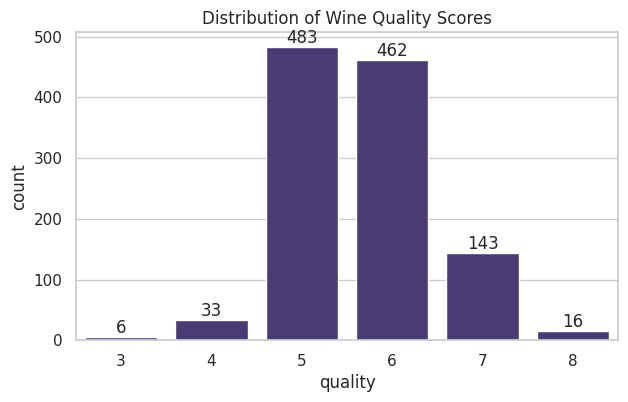

In [6]:
counts = df["quality"].value_counts().sort_index()
pct = (counts / len(df) * 100).round(2)
print(pd.DataFrame({"count": counts, "percent": pct}))

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="quality", ax=ax)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
ax.set_title("Distribution of Wine Quality Scores")
plt.show()

## 2. Exploratory Data Analysis

### 2.1 Distribution plots for all chemical features


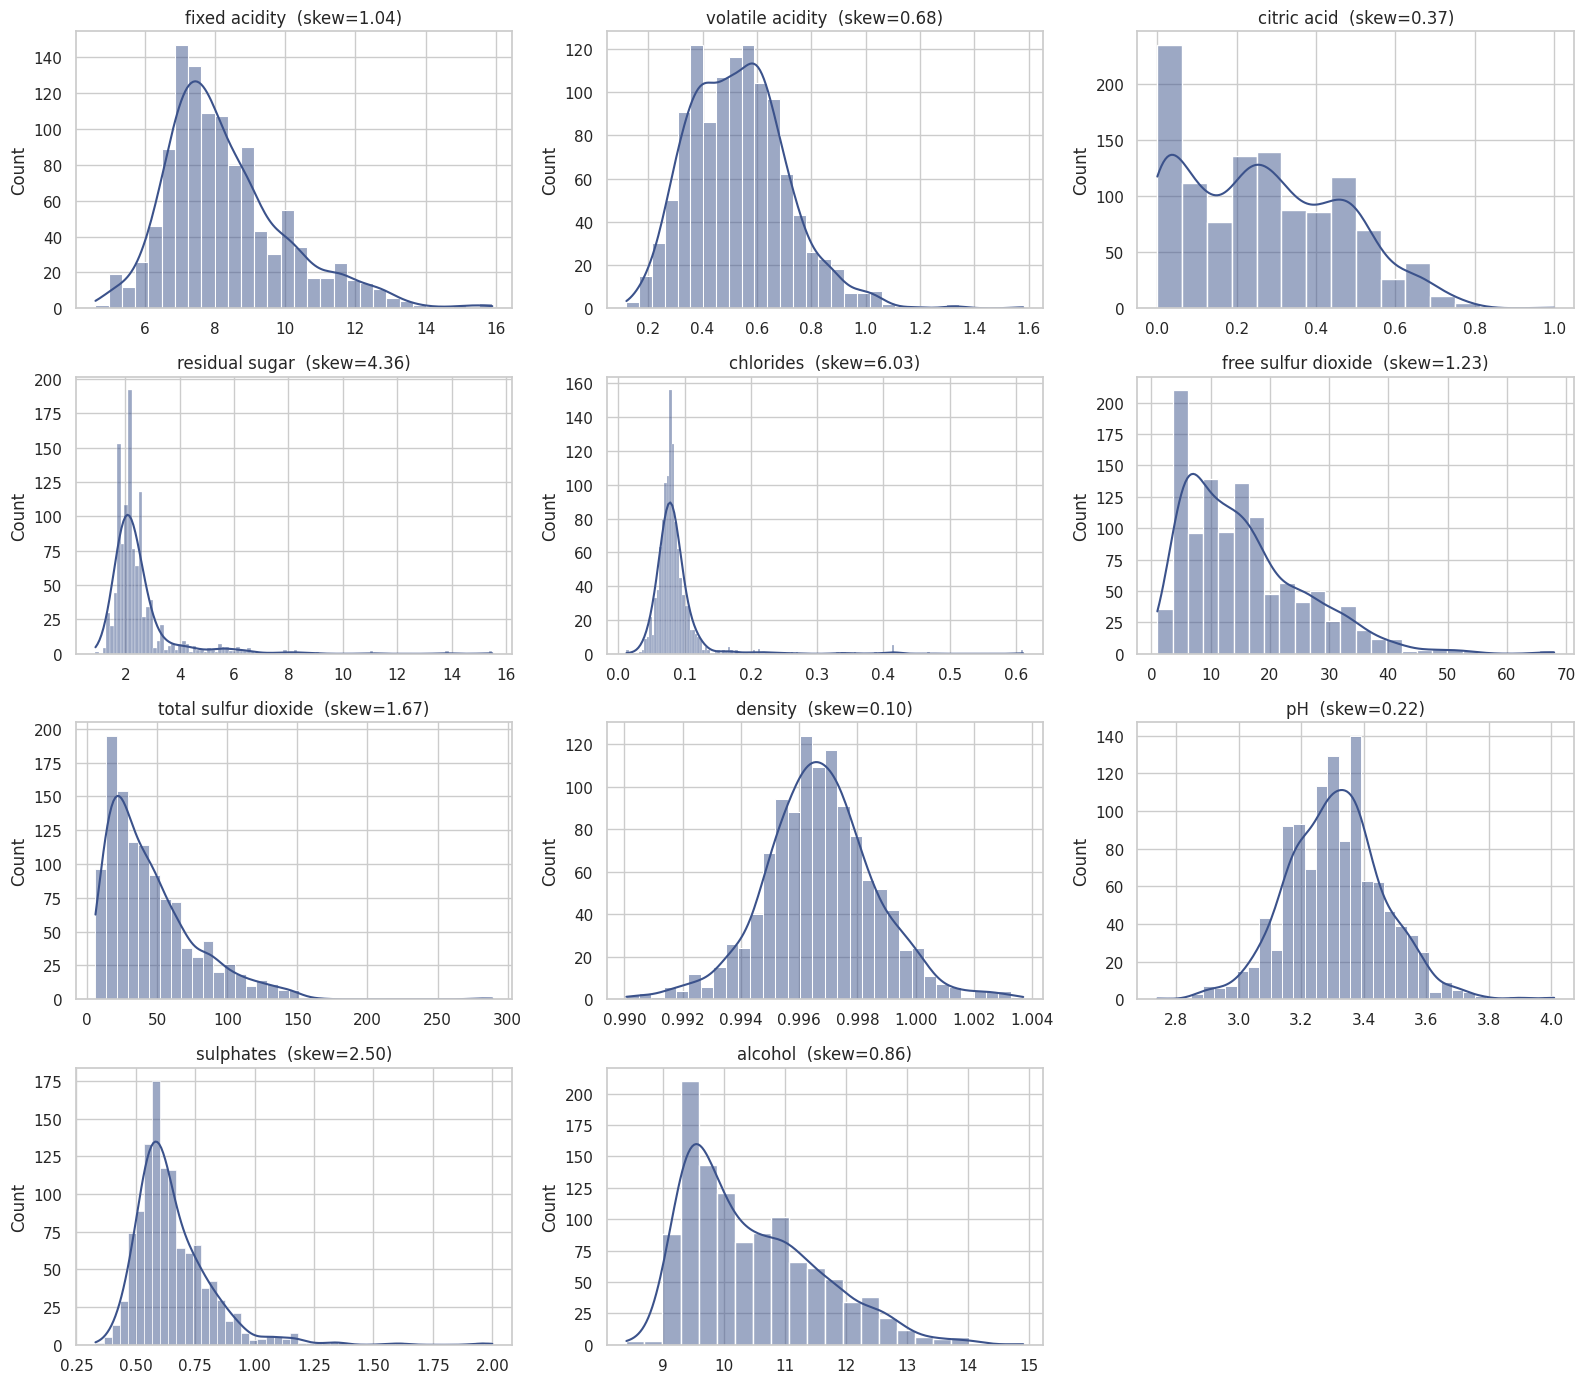

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(df[col], kde=True, ax=ax, color="#3b528b")
    ax.set_title(f"{col}  (skew={df[col].skew():.2f})")
    ax.set_xlabel("")
for ax in axes.ravel()[len(features):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

**Observations**
- `residual sugar`, `chlorides`, `sulphates`, `total sulfur dioxide` strongly **right-skewed** hain, aur inme outliers kaafi hain.
- `density`, `pH` roughly normal hain.
- Features ki scales bahut alag hain (density ~1 vs total SO₂ ~100) → **SVC aur SGD ke liye scaling zaroori** hai. Random Forest ko scaling ki zaroorat nahi.

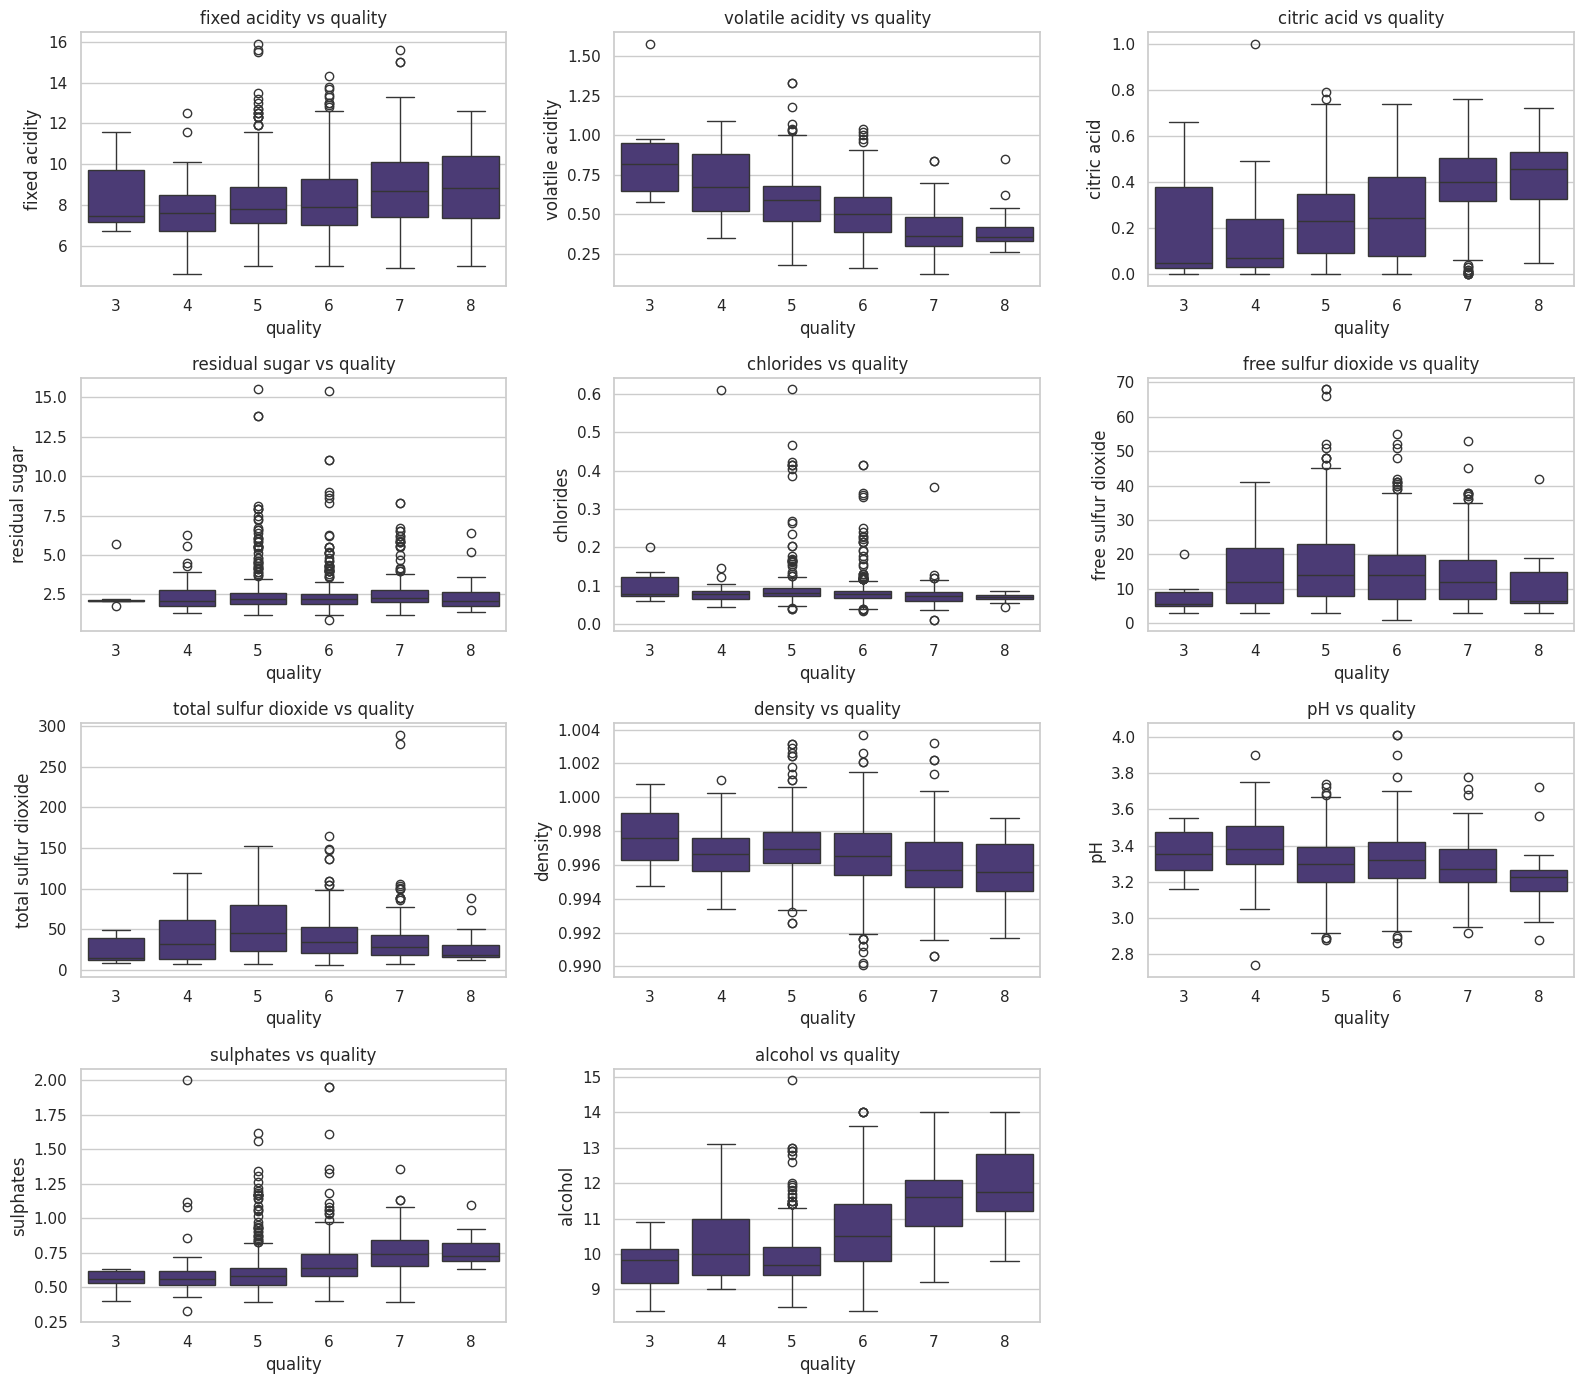

In [8]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
for ax, col in zip(axes.ravel(), features):
    sns.boxplot(data=df, x="quality", y=col, ax=ax)
    ax.set_title(f"{col} vs quality")
for ax in axes.ravel()[len(features):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

Boxplots se dikhta hai ki **alcohol** quality ke saath clearly badhta hai, aur **volatile acidity** quality ke saath ghat'ta hai. Yeh dono sabse informative features lag rahe hain.

### 2.2 Correlation heatmap

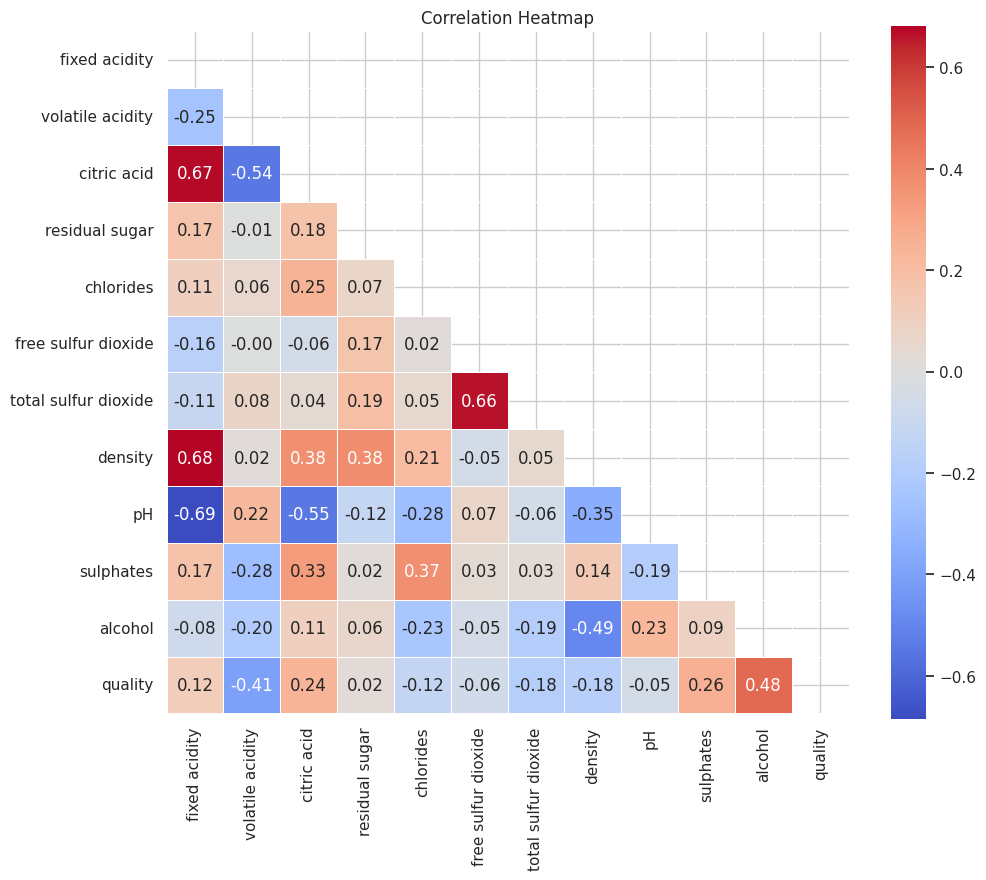

Correlation with quality:
alcohol                 0.485
sulphates               0.258
citric acid             0.241
fixed acidity           0.122
residual sugar          0.022
pH                     -0.052
free sulfur dioxide    -0.063
chlorides              -0.124
density                -0.175
total sulfur dioxide   -0.183
volatile acidity       -0.407
Name: quality, dtype: float64


In [9]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=.5)
plt.title("Correlation Heatmap")
plt.show()

print("Correlation with quality:")
print(corr["quality"].drop("quality").sort_values(ascending=False).round(3))

**Observations**
- Quality ke saath sabse positive correlation: **alcohol**, **sulphates**, **citric acid**.
- Sabse negative: **volatile acidity**, **total sulfur dioxide**, **density**.
- Multicollinearity: `fixed acidity` ↔ `density`, `fixed acidity` ↔ `citric acid`, `fixed acidity` ↔ `pH`, aur `free SO₂` ↔ `total SO₂` strongly correlated hain. Tree-based model isse zyada affect nahi hota, par linear models (SGD) ke coefficients thode unstable ho sakte hain.

## 3. Class Imbalance Discussion

Imbalance ratio (max/min class): 80.5


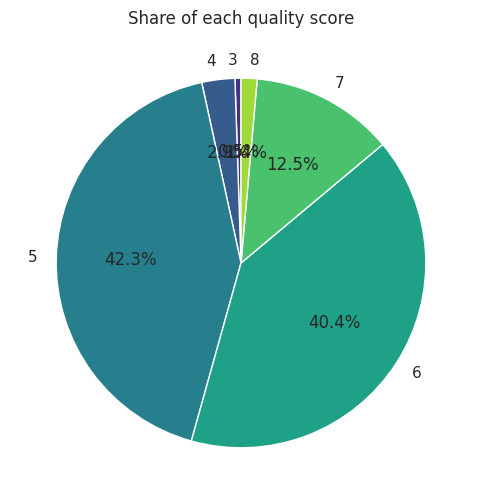

In [10]:
imb = df["quality"].value_counts().sort_index()
print("Imbalance ratio (max/min class):", round(imb.max() / imb.min(), 1))

plt.figure(figsize=(6, 6))
plt.pie(imb, labels=imb.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("viridis", len(imb)))
plt.title("Share of each quality score")
plt.show()

**Kya kuch classes underrepresented hain? — Haan.**

- Quality **5 aur 6** milkar dataset ka ~83% hain.
- Quality **3 (6 samples)**, **4 (33 samples)** aur **8 (16 samples)** bahut kam hain. Imbalance ratio ~80:1.
- Extreme scores (3, 8) wali wines rare hain — yeh domain mein bhi natural hai.

**Modelling par asar**
1. **Accuracy misleading** ho jaati hai — model sirf 5/6 predict karke bhi ~83% accuracy la sakta hai.
2. Rare classes ke liye model ko seekhne ke liye bahut kam examples milte hain → recall ~0 ho jaata hai.
3. Train/test split mein rare class test set mein 1–2 samples hi la sakti hai → metrics bahut noisy.
4. **Stratified split** zaroori hai, aur sirf accuracy nahi balki **precision / recall / F1 (per class)** dekhna chahiye.

**Mitigation options:** class merging (binning), `class_weight="balanced"`, resampling (SMOTE). Hum pehle do use karenge.

## 4. Feature Engineering — Quality Binning

Original 6-class problem mein classes 3, 4, 8 itni choti hain ki koi bhi model unhe reliably predict nahi kar sakta. Isliye do binning options dekhte hain:

| Option | Mapping | Pros | Cons |
|---|---|---|---|
| **Binary** | Bad: 3–5, Good: 6–8 | Balanced classes, simple business question ("kya yeh wine acchi hai?") | Information loss |
| **3-class** | Low: 3–5, Medium: 6, High: 7–8 | Zyada granular | High class sirf ~14%, medium bahut overlap karta hai |

Binary:
quality_binary
good (6-8)    621
bad (3-5)     522
Name: count, dtype: int64

3-class:
quality_3class
low       522
medium    462
high      159
Name: count, dtype: int64


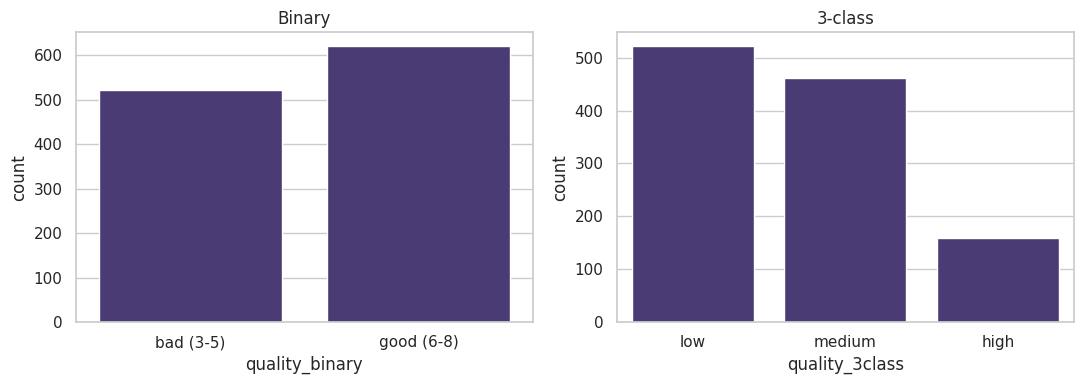

In [11]:
df["quality_binary"] = (df["quality"] >= 6).astype(int)           # 1 = good, 0 = bad
df["quality_3class"] = pd.cut(df["quality"], bins=[0, 5, 6, 10], labels=["low", "medium", "high"])

print("Binary:");  print(df["quality_binary"].value_counts().rename({0: "bad (3-5)", 1: "good (6-8)"}))
print("\n3-class:"); print(df["quality_3class"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x="quality_binary", ax=axes[0]); axes[0].set_xticklabels(["bad (3-5)", "good (6-8)"]); axes[0].set_title("Binary")
sns.countplot(data=df, x="quality_3class", order=["low", "medium", "high"], ax=axes[1]); axes[1].set_title("3-class")
plt.tight_layout(); plt.show()

### Decision: **Binary (Good vs Bad)** ko primary target banate hain

**Justification**
1. **Balanced classes** (~54% good / 46% bad) → accuracy ek meaningful metric ban jaati hai, aur imbalance problem lagbhag khatam.
2. Extreme classes (3, 4, 8) ki sparsity khatam — har class mein hazaaron nahi par kaafi hundreds samples hain.
3. **Practical use:** deployment mein aksar sawaal yahi hota hai ki "batch accept karein ya reject?" — fine-grained 3 vs 4 ka fark kam important hai.
4. Quality ratings human tasters ke subjective scores hain; ek adjacent score (5 vs 6) ke beech noise hota hai. Binary threshold is noise ko kam karta hai.

Neeche hum 3-class variant ko bhi ek **sanity-check experiment** ke taur par chalayenge (Section 9.1).

## 5. Train / Test Split (Stratified)

In [12]:
X = df[features]
y = df["quality_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nClass ratio (full / train / test):")
print(pd.DataFrame({
    "full":  y.value_counts(normalize=True),
    "train": y_train.value_counts(normalize=True),
    "test":  y_test.value_counts(normalize=True),
}).round(3))

Train: (914, 11)  Test: (229, 11)

Class ratio (full / train / test):
                 full  train   test
quality_binary                     
1               0.543  0.544  0.541
0               0.457  0.456  0.459


## 6. Train the 3 Classifiers

- **Random Forest** — scaling ki zaroorat nahi.
- **SGD Classifier** aur **SVC** — distance/gradient based hain, isliye `StandardScaler` ko **Pipeline** ke andar rakha hai taaki scaling sirf train data par fit ho (**data leakage nahi hoga**).
- Teeno models ke liye `GridSearchCV` (5-fold stratified) se chhota hyperparameter tuning kiya hai — sirf training set par.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Random Forest": (
        Pipeline([("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))]),
        {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 10, 20], "clf__min_samples_leaf": [1, 2]},
    ),
    "SGD": (
        Pipeline([("scaler", StandardScaler()),
                  ("clf", SGDClassifier(random_state=RANDOM_STATE, max_iter=2000, tol=1e-3))]),
        {"clf__loss": ["hinge", "log_loss", "modified_huber"],
         "clf__alpha": [1e-4, 1e-3, 1e-2, 1e-1],
         "clf__penalty": ["l2", "l1"]},
    ),
    "SVC": (
        Pipeline([("scaler", StandardScaler()), ("clf", SVC(random_state=RANDOM_STATE))]),
        {"clf__C": [0.1, 1, 10, 50], "clf__gamma": ["scale", 0.05, 0.1], "clf__kernel": ["rbf", "linear"]},
    ),
}

best_models, cv_scores = {}, {}
for name, (pipe, grid) in models.items():
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="accuracy", n_jobs=-1)
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    cv_scores[name] = gs.best_score_
    print(f"{name:14s} | best CV acc = {gs.best_score_:.4f} | params = {gs.best_params_}")

Random Forest  | best CV acc = 0.7812 | params = {'clf__max_depth': 10, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200}
SGD            | best CV acc = 0.7505 | params = {'clf__alpha': 0.1, 'clf__loss': 'modified_huber', 'clf__penalty': 'l1'}
SVC            | best CV acc = 0.7625 | params = {'clf__C': 1, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}


## 7. Evaluation — Accuracy, Classification Report, Confusion Matrix

In [14]:
labels = ["bad (3-5)", "good (6-8)"]
preds, results = {}, []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    preds[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    print("=" * 60)
    print(f"{name}   |   Test Accuracy: {acc:.4f}")
    print("=" * 60)
    print(classification_report(y_test, y_pred, target_names=labels))

Random Forest   |   Test Accuracy: 0.8210
              precision    recall  f1-score   support

   bad (3-5)       0.83      0.76      0.80       105
  good (6-8)       0.81      0.87      0.84       124

    accuracy                           0.82       229
   macro avg       0.82      0.82      0.82       229
weighted avg       0.82      0.82      0.82       229

SGD   |   Test Accuracy: 0.7773
              precision    recall  f1-score   support

   bad (3-5)       0.74      0.79      0.76       105
  good (6-8)       0.81      0.77      0.79       124

    accuracy                           0.78       229
   macro avg       0.78      0.78      0.78       229
weighted avg       0.78      0.78      0.78       229

SVC   |   Test Accuracy: 0.7860
              precision    recall  f1-score   support

   bad (3-5)       0.77      0.75      0.76       105
  good (6-8)       0.80      0.81      0.80       124

    accuracy                           0.79       229
   macro avg       0.7

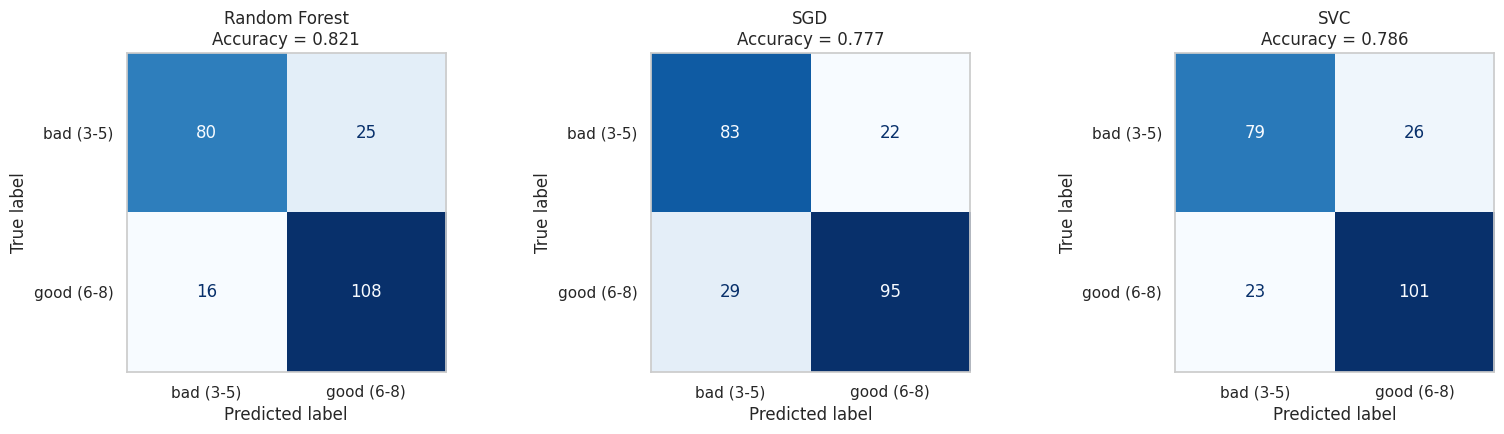

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, y_pred) in zip(axes, preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=labels).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(f"{name}\nAccuracy = {accuracy_score(y_test, y_pred):.3f}")
    ax.grid(False)
plt.tight_layout()
plt.show()

## 8. Random Forest — Feature Importance


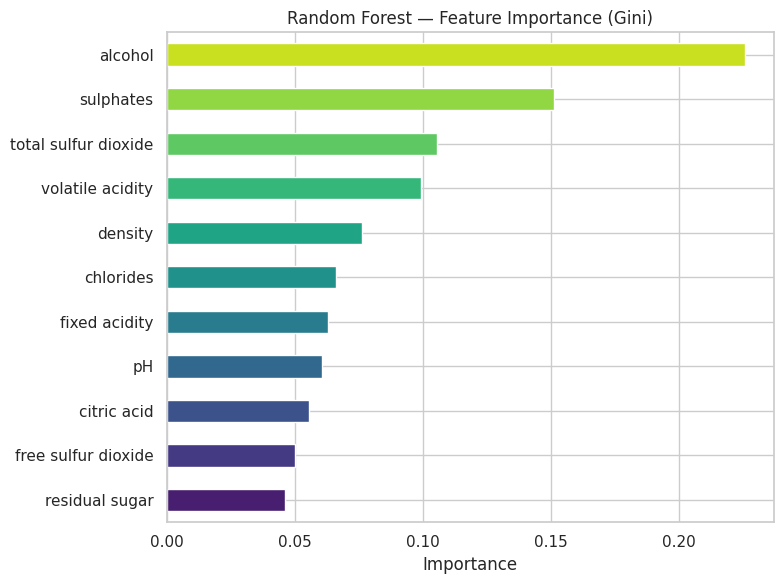

alcohol                 0.2257
sulphates               0.1512
total sulfur dioxide    0.1056
volatile acidity        0.0994
density                 0.0762
chlorides               0.0662
fixed acidity           0.0629
pH                      0.0608
citric acid             0.0555
free sulfur dioxide     0.0501
residual sugar          0.0464
dtype: float64


In [16]:
rf = best_models["Random Forest"].named_steps["clf"]
imp = pd.Series(rf.feature_importances_, index=features).sort_values()

plt.figure(figsize=(8, 6))
imp.plot(kind="barh", color=sns.color_palette("viridis", len(imp)))
plt.title("Random Forest — Feature Importance (Gini)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(imp.sort_values(ascending=False).round(4))

**Interpretation:** `alcohol` (~22.6%) sabse important feature hai, uske baad `sulphates`, `total sulfur dioxide` aur `volatile acidity` aate hain — yeh EDA/correlation ke findings se match karta hai. Ye bhi dhyaan rahe ki Gini importance correlated features ke beech importance baant deta hai, isliye density/fixed acidity jaise features ki importance thodi diluted dikh sakti hai.

## 9. Model Comparison Table

In [17]:
rows = []
for name, y_pred in preds.items():
    rows.append({
        "Model": name,
        "CV Accuracy (train)": cv_scores[name],
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Precision (weighted)": precision_score(y_test, y_pred, average="weighted"),
        "Recall (weighted)": recall_score(y_test, y_pred, average="weighted"),
        "F1 (weighted)": f1_score(y_test, y_pred, average="weighted"),
        "F1 (bad)": f1_score(y_test, y_pred, pos_label=0),
        "F1 (good)": f1_score(y_test, y_pred, pos_label=1),
    })
comparison = pd.DataFrame(rows).set_index("Model").round(4)
comparison.style.background_gradient(cmap="YlGn", axis=0).format("{:.4f}")

,CV Accuracy (train),Test Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),F1 (bad),F1 (good)
Model,,,,,,,
Random Forest,0.7812,0.8210,0.8218,0.8210,0.8201,0.7960,0.8405
SGD,0.7505,0.7773,0.7795,0.7773,0.7777,0.7650,0.7884
SVC,0.7625,0.7860,0.7858,0.7860,0.7858,0.7633,0.8048


Random Forest : 0.7857 +/- 0.0133
SGD           : 0.7542 +/- 0.0124
SVC           : 0.7550 +/- 0.0132


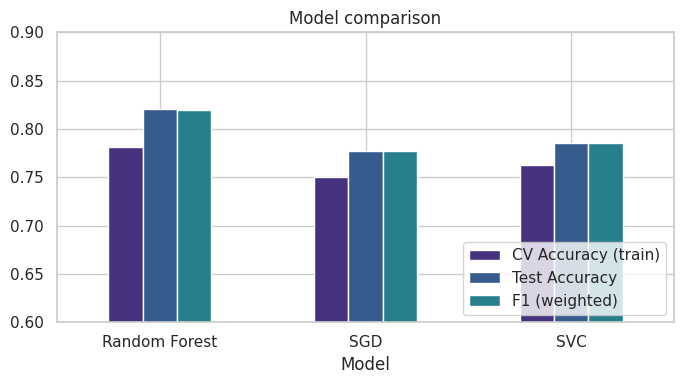

In [18]:
# Stability check: 5-fold CV on the FULL dataset -> mean +/- std
# (note: hyperparameters were tuned on the train split, so this is slightly optimistic)
stab = {}
for name, model in best_models.items():
    s = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    stab[name] = (s.mean(), s.std())
    print(f"{name:14s}: {s.mean():.4f} +/- {s.std():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
comparison[["CV Accuracy (train)", "Test Accuracy", "F1 (weighted)"]].plot(kind="bar", ax=ax, rot=0)
ax.set_ylim(0.6, 0.9); ax.set_title("Model comparison"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

### 9.1 Sanity-check: 3-class problem (Low / Medium / High)

In [19]:
y3 = df["quality_3class"].astype(str)
X_tr3, X_te3, y_tr3, y_te3 = train_test_split(X, y3, test_size=0.2, stratify=y3, random_state=RANDOM_STATE)

rows3 = []
for name, model in best_models.items():
    from sklearn.base import clone
    m = clone(model).fit(X_tr3, y_tr3)
    p = m.predict(X_te3)
    rows3.append({"Model": name, "Accuracy": accuracy_score(y_te3, p),
                  "Macro F1": f1_score(y_te3, p, average="macro"),
                  "F1 (high)": f1_score(y_te3, p, labels=["high"], average="macro")})
print(pd.DataFrame(rows3).set_index("Model").round(4))

               Accuracy  Macro F1  F1 (high)
Model                                       
Random Forest    0.6856    0.6651     0.6038
SGD              0.6245    0.4572     0.0588
SVC              0.6463    0.5858     0.4167


3-class setup mein accuracy aur macro-F1 dono gir jaate hain, aur **'high' class** ke liye F1 khaas taur par kamzor rehta hai — yeh binary binning ke faisle ko support karta hai.

## 10. Conclusion

### Final comparison (binary target: good = quality ≥ 6)

| Model | CV Acc (train) | Test Acc | F1 (weighted) | 5-fold CV (full data) | 3-class Macro F1 |
|---|---|---|---|---|---|
| **Random Forest** | 0.781 | **0.821** | **0.82** | **0.786 ± 0.013** | **0.665** |
| SVC (RBF) | 0.763 | 0.786 | 0.79 | 0.755 ± 0.013 | 0.586 |
| SGD | 0.751 | 0.777 | 0.78 | 0.754 ± 0.009 | 0.446 |

### Key findings
- Original 6-class target heavily imbalanced tha (classes 3, 4, 8 sirf ~5% data), isliye **binary binning (good/bad)** use ki — isse classes balanced ho gayi (54% / 46%).
- **Alcohol** sabse important predictor hai, uske baad **sulphates**, **total sulfur dioxide**, aur **volatile acidity** — yeh EDA ke correlations se consistent hai.
- **Random Forest** har metric par best raha: test accuracy ~82%, dono classes mein balanced precision/recall, aur 3-class setting mein bhi sabse robust (SGD 'high' class ko almost predict hi nahi kar paaya).
- **SVC** doosre number par raha (~79%) — scaling ke saath achha, par RF se ~3 points peeche aur probability estimates ke liye extra calibration chahiye.
- **SGD** sabse fast aur lightweight hai, par linear decision boundary wine chemistry ke non-linear relationships capture nahi kar paati → lowest accuracy.

### Deployment recommendation: **Random Forest** ✅
1. Sabse high aur stable accuracy / F1 (CV aur test dono mein).
2. Non-linear relationships aur feature interactions naturally handle karta hai; skewed features/outliers par robust; **scaling ki zaroorat nahi** → simple serving pipeline.
3. **Feature importance** se interpretability milti hai — winemakers ko batata hai ki alcohol, sulphates aur volatile acidity control karna quality ke liye important hai.
4. Inference fast hai, aur hyperparameters (`max_depth`, `min_samples_leaf`) overfitting control karte hain.

### Limitations & next steps
- Dataset chhota hai (1143 rows) → test set sirf 229 samples ka hai, isliye ±2–3% ka difference noise ke andar ho sakta hai (RF ka lead SGD/SVC se isse zyada hai, par repeated CV se confirm karna accha hoga).
- Quality subjective human rating hai, isliye ~80% accuracy ke upar jaana mushkil hai.
- Aage try kar sakte hain: SMOTE / `class_weight` ke saath multi-class, Gradient Boosting (XGBoost/LightGBM), feature selection (correlated features hatana), probability calibration, aur threshold tuning.
